In [1]:
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

from nbtools import auto_plot_style
from nbtools import normhist, normhist2d

In [2]:
%matplotlib inline
auto_plot_style()

In [68]:
path = Path("/home/gonzalo/data/COLINA/mc/ptfe_80/")

# S1

In [69]:
filename_ptfe_true_fp_true   = path / "s1_ptfe_true_fp_true/merged.h5"
filename_ptfe_true_fp_false  = path / "s1_ptfe_true_fp_false/merged.h5"
filename_ptfe_false_fp_true  = path / "s1_ptfe_false_fp_true/merged.h5"
filename_ptfe_false_fp_false = path / "s1_ptfe_false_fp_false/merged.h5"

### Check event distribution

In [70]:
s1_interactions = pd.read_hdf(filename_ptfe_true_fp_true, "/MC/interactions")

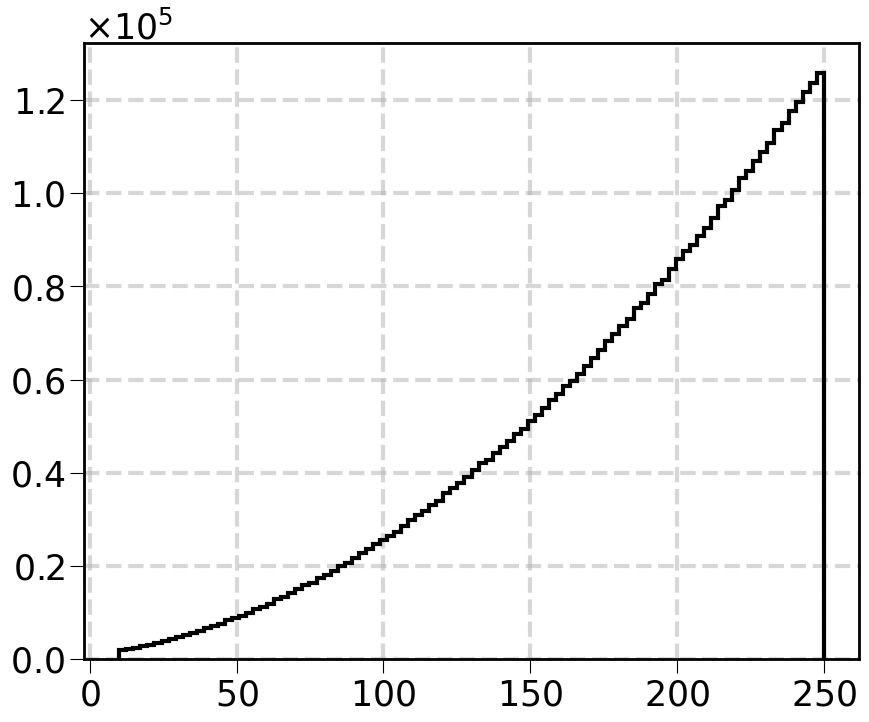

In [71]:
df = s1_interactions

plt.hist(df.z, 100, histtype="step")
plt.grid()

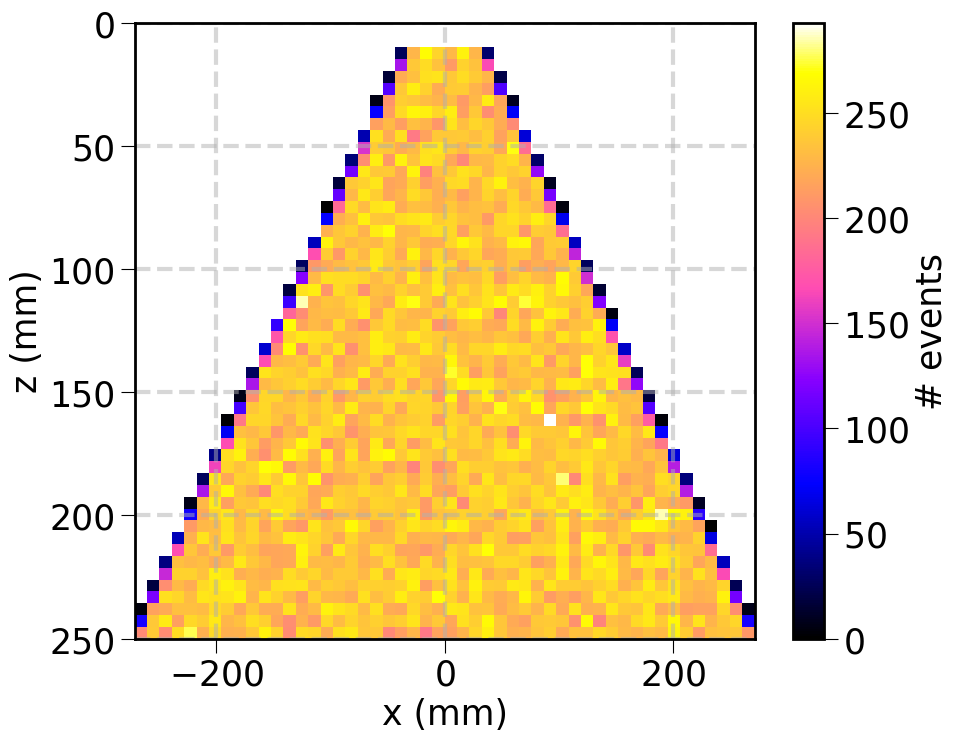

In [72]:
df = s1_interactions
df = df.loc[np.abs(df.y) < 10]

plt.hist2d(df.x, -df.z, 50, cmin=1, vmin=0)
#plt.gca().set_aspect(1)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.colorbar().set_label("# events")
plt.yticks(plt.yticks()[0], labels=list(map(lambda x: str(int(x)), -plt.yticks()[0])))
plt.grid()

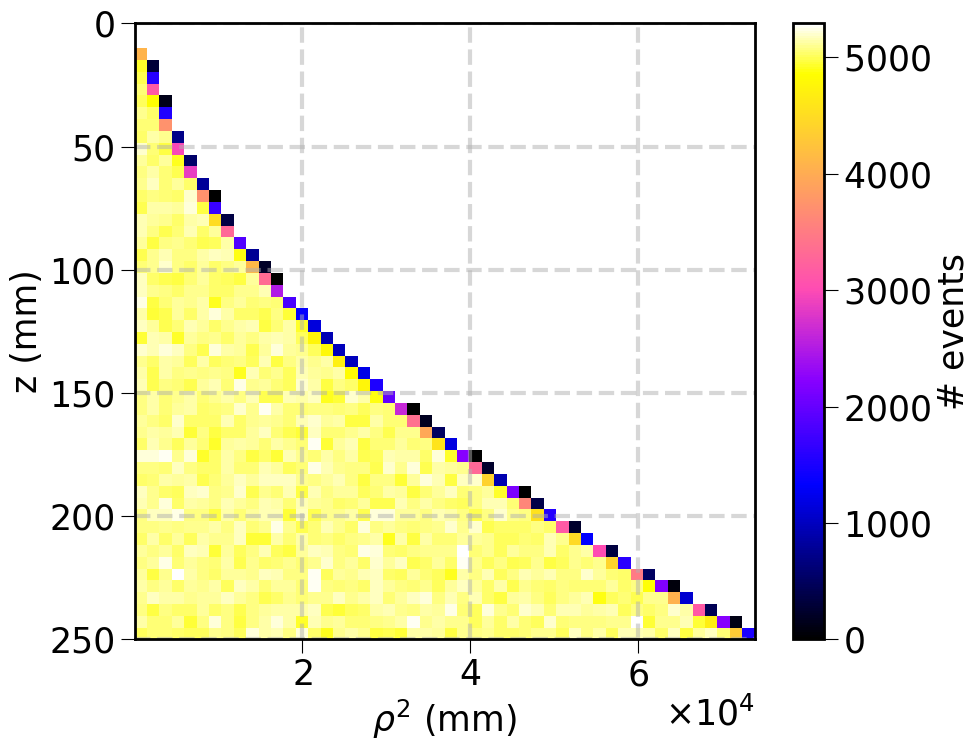

In [73]:
df = s1_interactions

rho2 = df.x**2 + df.y**2
plt.hist2d(rho2, -df.z, 50, cmin=1, vmin=0)
#plt.gca().set_aspect(1)
plt.xlabel("$\\rho^2$ (mm)")
plt.ylabel("z (mm)")
plt.colorbar().set_label("# events")
plt.yticks(plt.yticks()[0], labels=list(map(lambda x: str(int(x)), -plt.yticks()[0])))
plt.grid()

### Compare sensor hits

In [74]:
int_true_true   = pd.read_hdf(filename_ptfe_true_fp_true  , "/MC/interactions").assign(rho = lambda df: (df.x**2 + df.y**2)**0.5)
int_true_false  = pd.read_hdf(filename_ptfe_true_fp_false , "/MC/interactions").assign(rho = lambda df: (df.x**2 + df.y**2)**0.5)
int_false_true  = pd.read_hdf(filename_ptfe_false_fp_true , "/MC/interactions").assign(rho = lambda df: (df.x**2 + df.y**2)**0.5)
int_false_false = pd.read_hdf(filename_ptfe_false_fp_false, "/MC/interactions").assign(rho = lambda df: (df.x**2 + df.y**2)**0.5)

ss_true_true   = pd.read_hdf(filename_ptfe_true_fp_true  , "/MC/sensor_hits")
ss_true_false  = pd.read_hdf(filename_ptfe_true_fp_false , "/MC/sensor_hits")
ss_false_true  = pd.read_hdf(filename_ptfe_false_fp_true , "/MC/sensor_hits")
ss_false_false = pd.read_hdf(filename_ptfe_false_fp_false, "/MC/sensor_hits")

In [75]:
def compute_lce(df_int, df_ss):
    return (df_ss
             .groupby("event")
             .time
             .count()
             .to_frame()
             .rename(columns=dict(time="ndet"))
             .join(df_int.set_index("event"), how="outer")
             .assign(lce=lambda df: df.ndet/df.n)
             .fillna(0.0)
            )

In [76]:
counts_true_true   = compute_lce(int_true_true  , ss_true_true  )
counts_true_false  = compute_lce(int_true_false , ss_true_false )
counts_false_true  = compute_lce(int_false_true , ss_false_true )
counts_false_false = compute_lce(int_false_false, ss_false_false)

/tmp/ipykernel_3084750/1656994181.py:5: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt>0, 100*lce/nevt, np.nan)


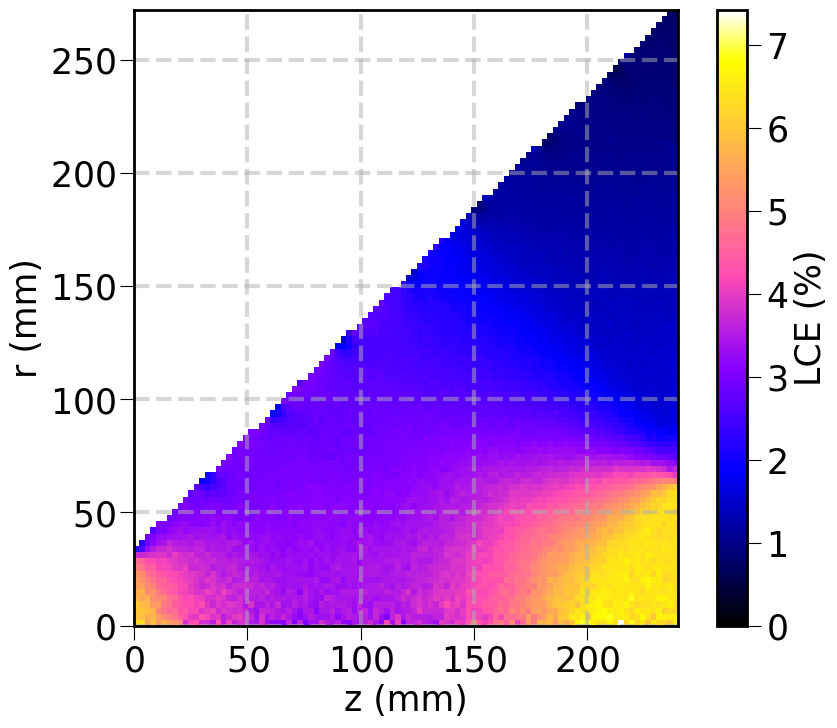

In [77]:
df = counts_true_true

nevt = np.histogram2d(df.z, df.rho, 100)[0]
lce  = np.histogram2d(df.z, df.rho, 100, weights=df.lce)[0]
lce  = np.where(nevt>0, 100*lce/nevt, np.nan)

#np.histogram2d(df.z, df.rho, 100, weights=df.ndet, cmin=1, vmin=0.1, norm=LogNorm())
#plt.gca().set_aspect(1)

#plt.imshow(lce.T, origin="lower", extent=(0, 240, 0, 32+240), norm=LogNorm(vmin=1e-2))
plt.imshow(lce.T, origin="lower", extent=(0, 240, 0, 32+240), vmin=0)

plt.colorbar().set_label("LCE (%)")
plt.xlabel("z (mm)")
plt.ylabel("r (mm)")
plt.grid()

/tmp/ipykernel_3084750/4000850215.py:11: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt>0, 100*lce/nevt, np.nan)


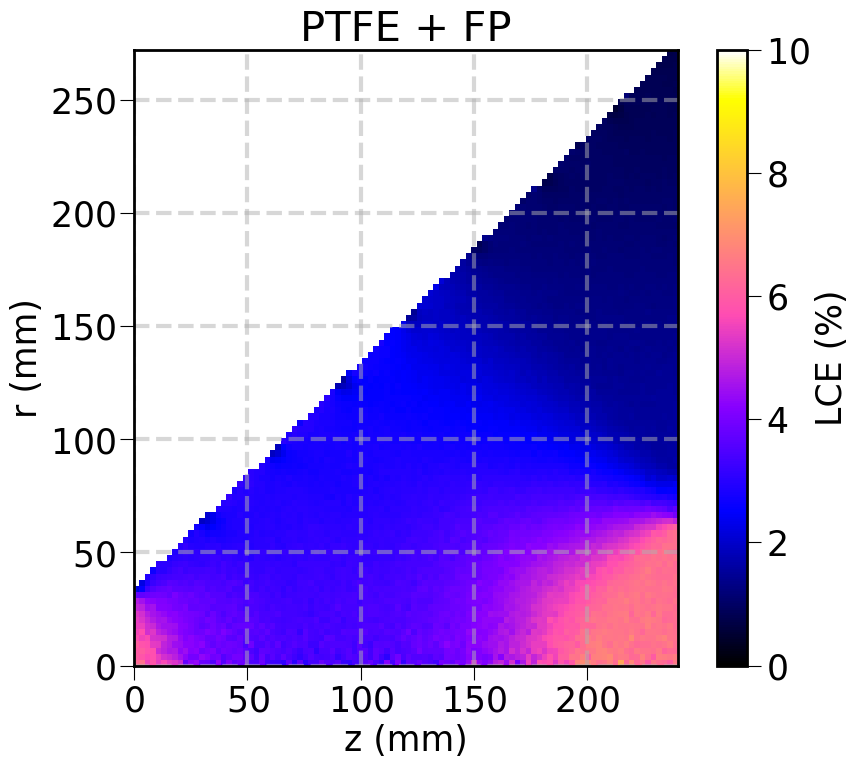

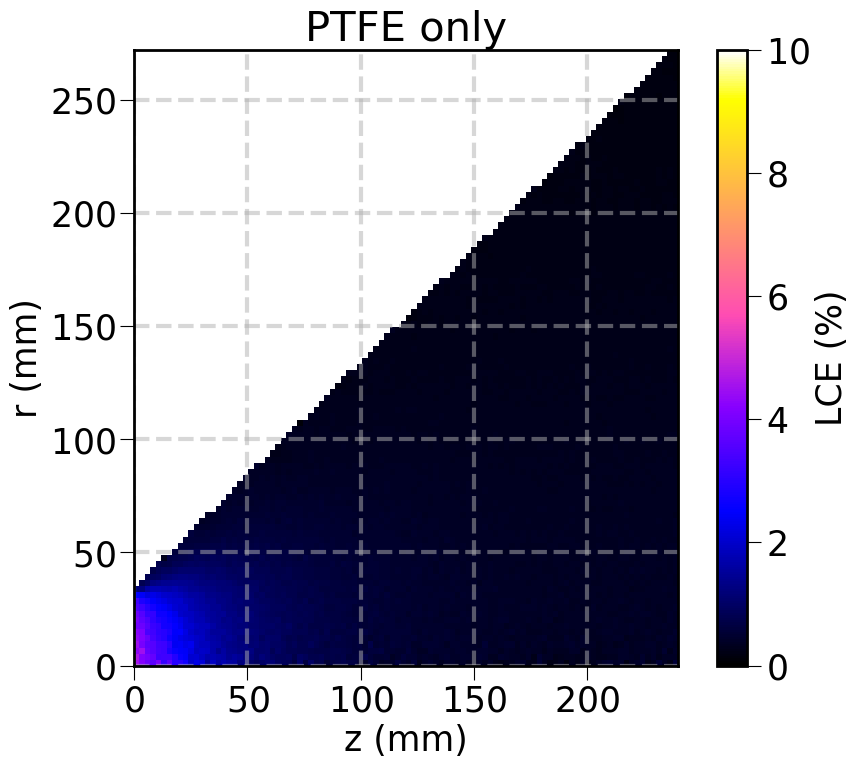

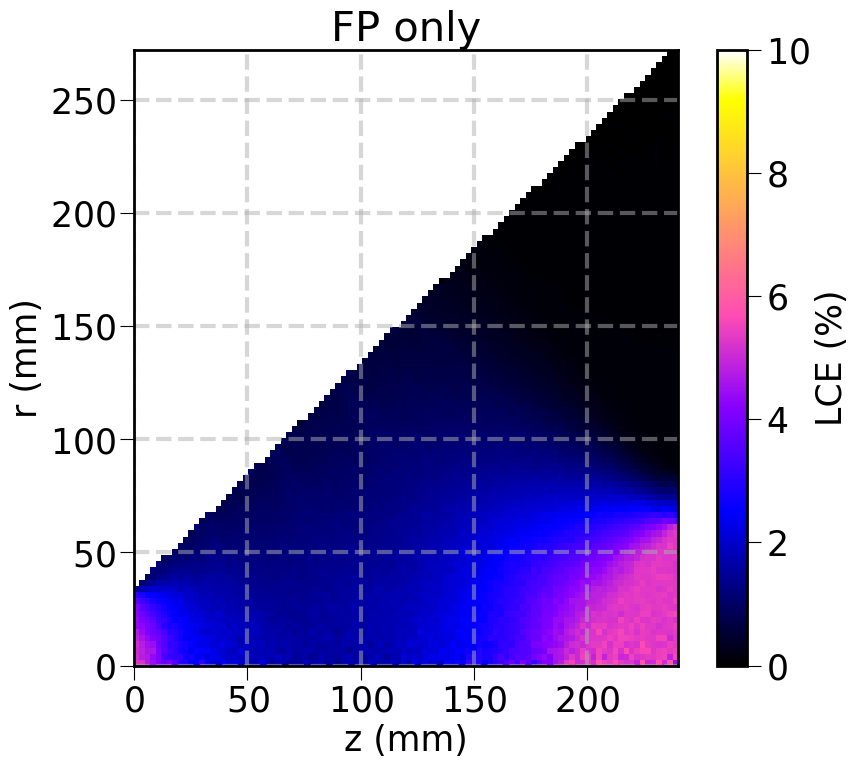

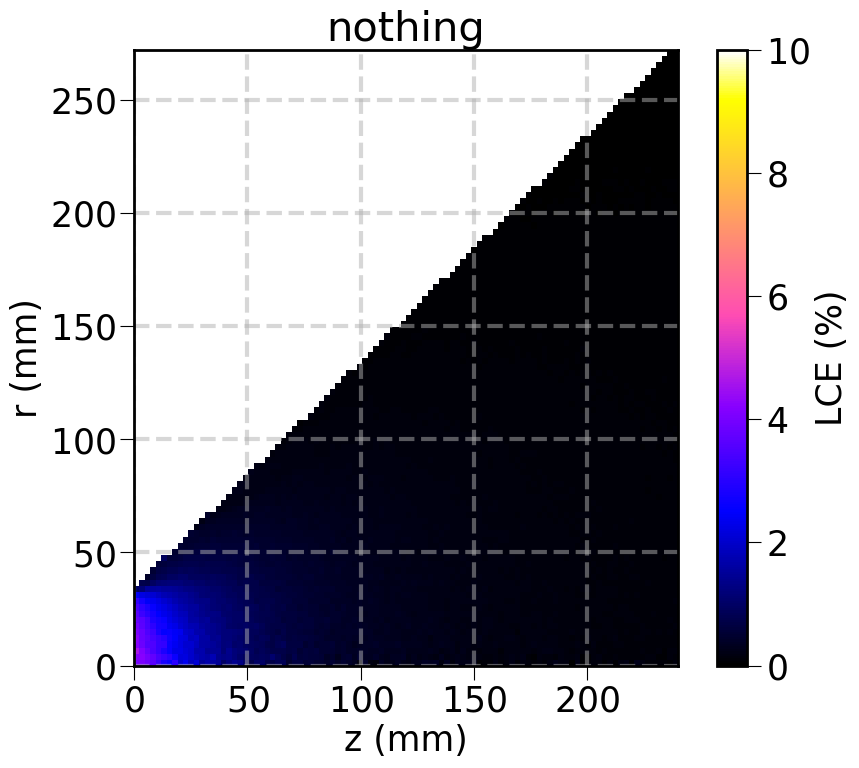

In [78]:
dfs = {
"PTFE + FP" : counts_true_true  ,
"PTFE only" : counts_true_false ,
"FP only"   : counts_false_true ,
"nothing"   : counts_false_false,
}

for title, df in dfs.items():
    nevt = np.histogram2d(df.z, df.rho, 100)[0]
    lce  = np.histogram2d(df.z, df.rho, 100, weights=df.lce)[0]
    lce  = np.where(nevt>0, 100*lce/nevt, np.nan)

    plt.figure()
    plt.imshow(lce.T, origin="lower", extent=(0, 240, 0, 32+240), vmin=0, vmax=10)

    plt.colorbar().set_label("LCE (%)")
    plt.xlabel("z (mm)")
    plt.ylabel("r (mm)")
    plt.title(title)
    plt.grid()

/tmp/ipykernel_3084750/824755725.py:14: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt, 100*lce/nevt, np.nan)


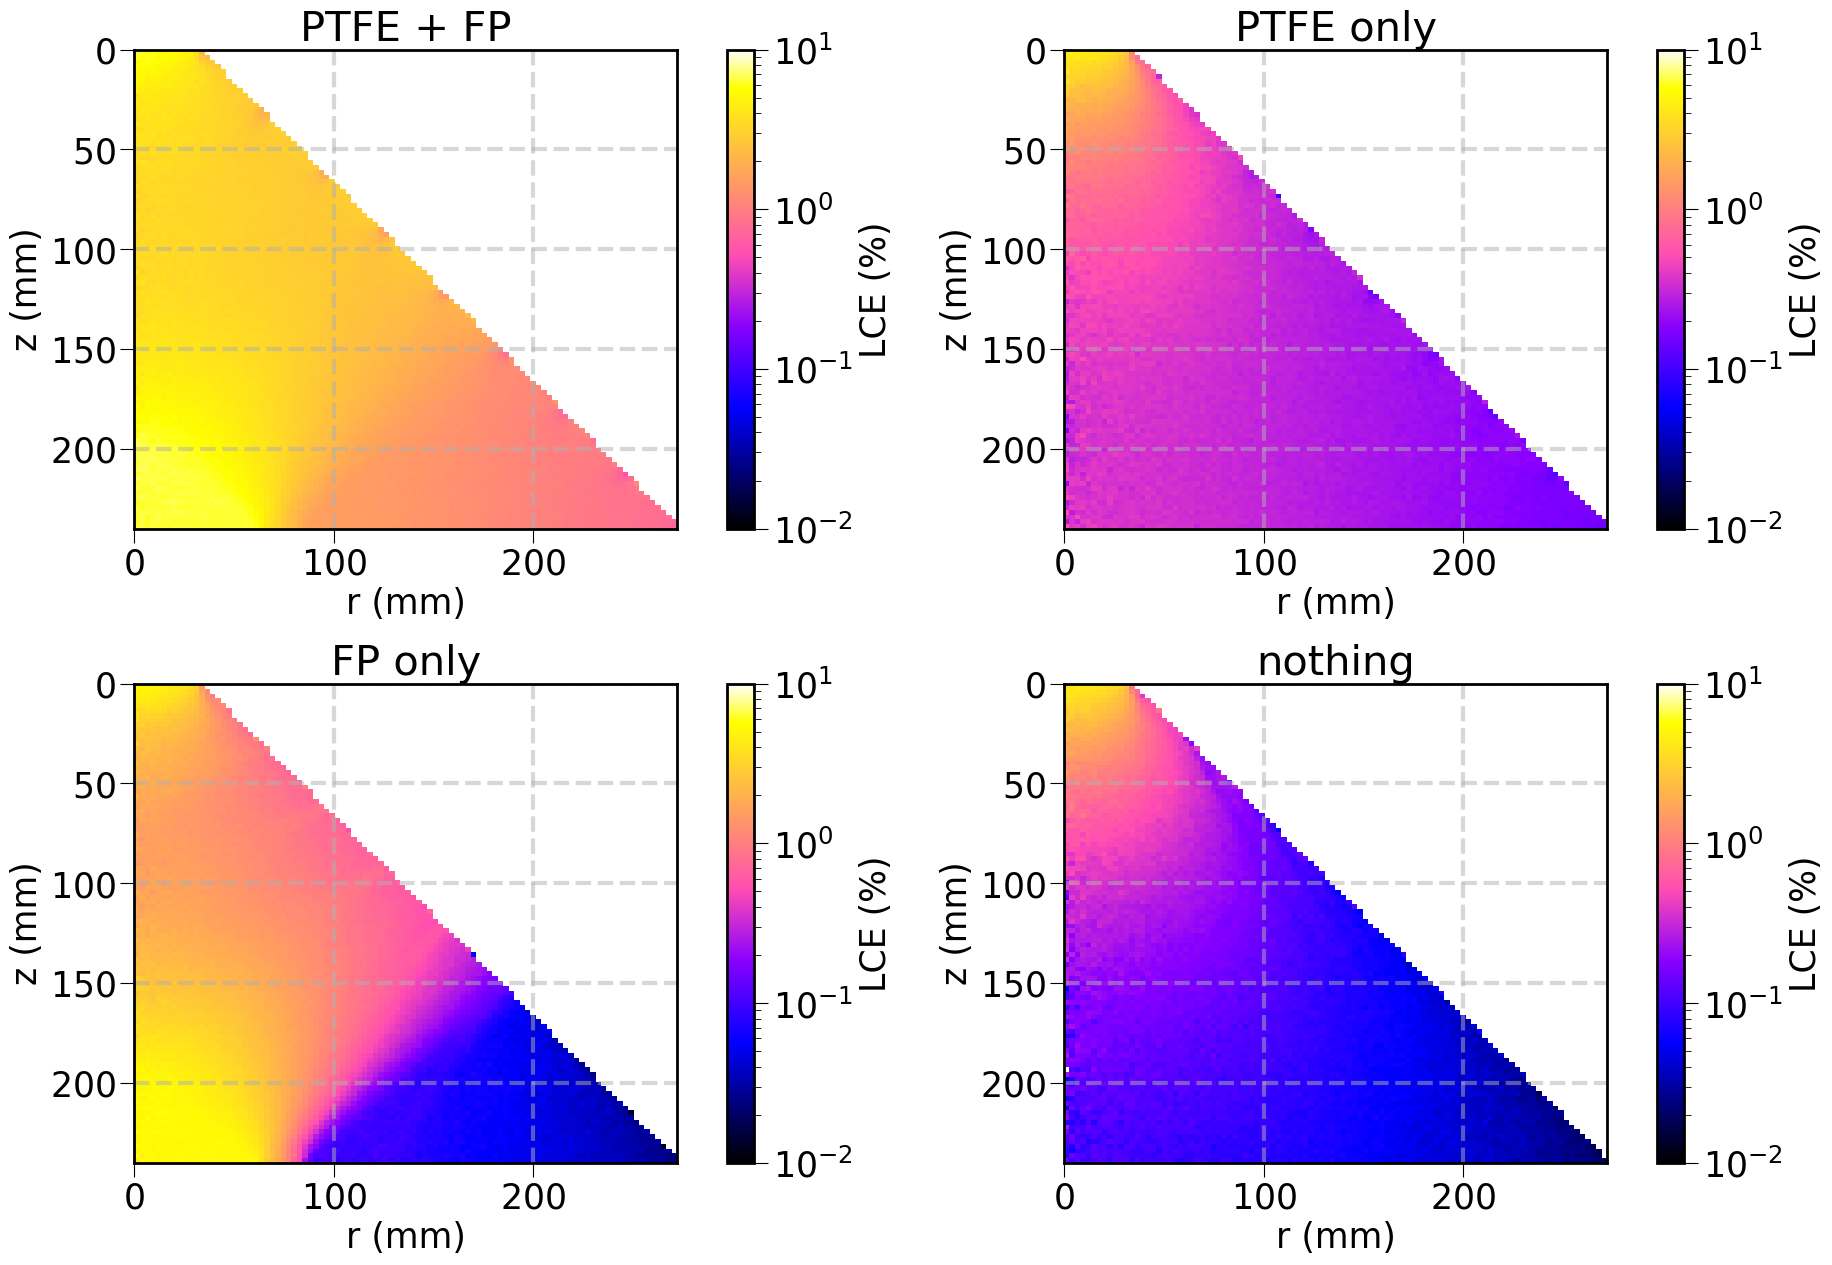

In [79]:
dfs = {
"PTFE + FP" : counts_true_true  ,
"PTFE only" : counts_true_false ,
"FP only"   : counts_false_true ,
"nothing"   : counts_false_false,
}

plt.figure(figsize=(20,20))
k = 0
for title, df in dfs.items():
    k += 1
    nevt = np.histogram2d(df.rho, -df.z, 100)[0]
    lce  = np.histogram2d(df.rho, -df.z, 100, weights=df.lce)[0]
    lce  = np.where(nevt, 100*lce/nevt, np.nan)

    plt.subplot(2, 2, k)
#    plt.imshow(lce.T, origin="lower", extent=(0, 240, 0, 32+240), vmin=0, vmax=2.5)
    plt.imshow(lce.T, origin="lower", extent=(0, 32+240, 240, 0), norm=LogNorm(vmin=1e-2, vmax=10))
    
    plt.xlabel("r (mm)")
    plt.ylabel("z (mm)")
    plt.title(title)
    plt.grid()

    divider = make_axes_locatable(plt.gca())
    cax = divider.append_axes("right", size="5%", pad=0.5)
    
    cb = plt.colorbar(cax=cax)
    cb.set_label("LCE (%)")
    
plt.subplots_adjust(wspace=.5, hspace=-.3)

/tmp/ipykernel_3084750/2204772718.py:12: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt, 100*lce/nevt, np.nan)


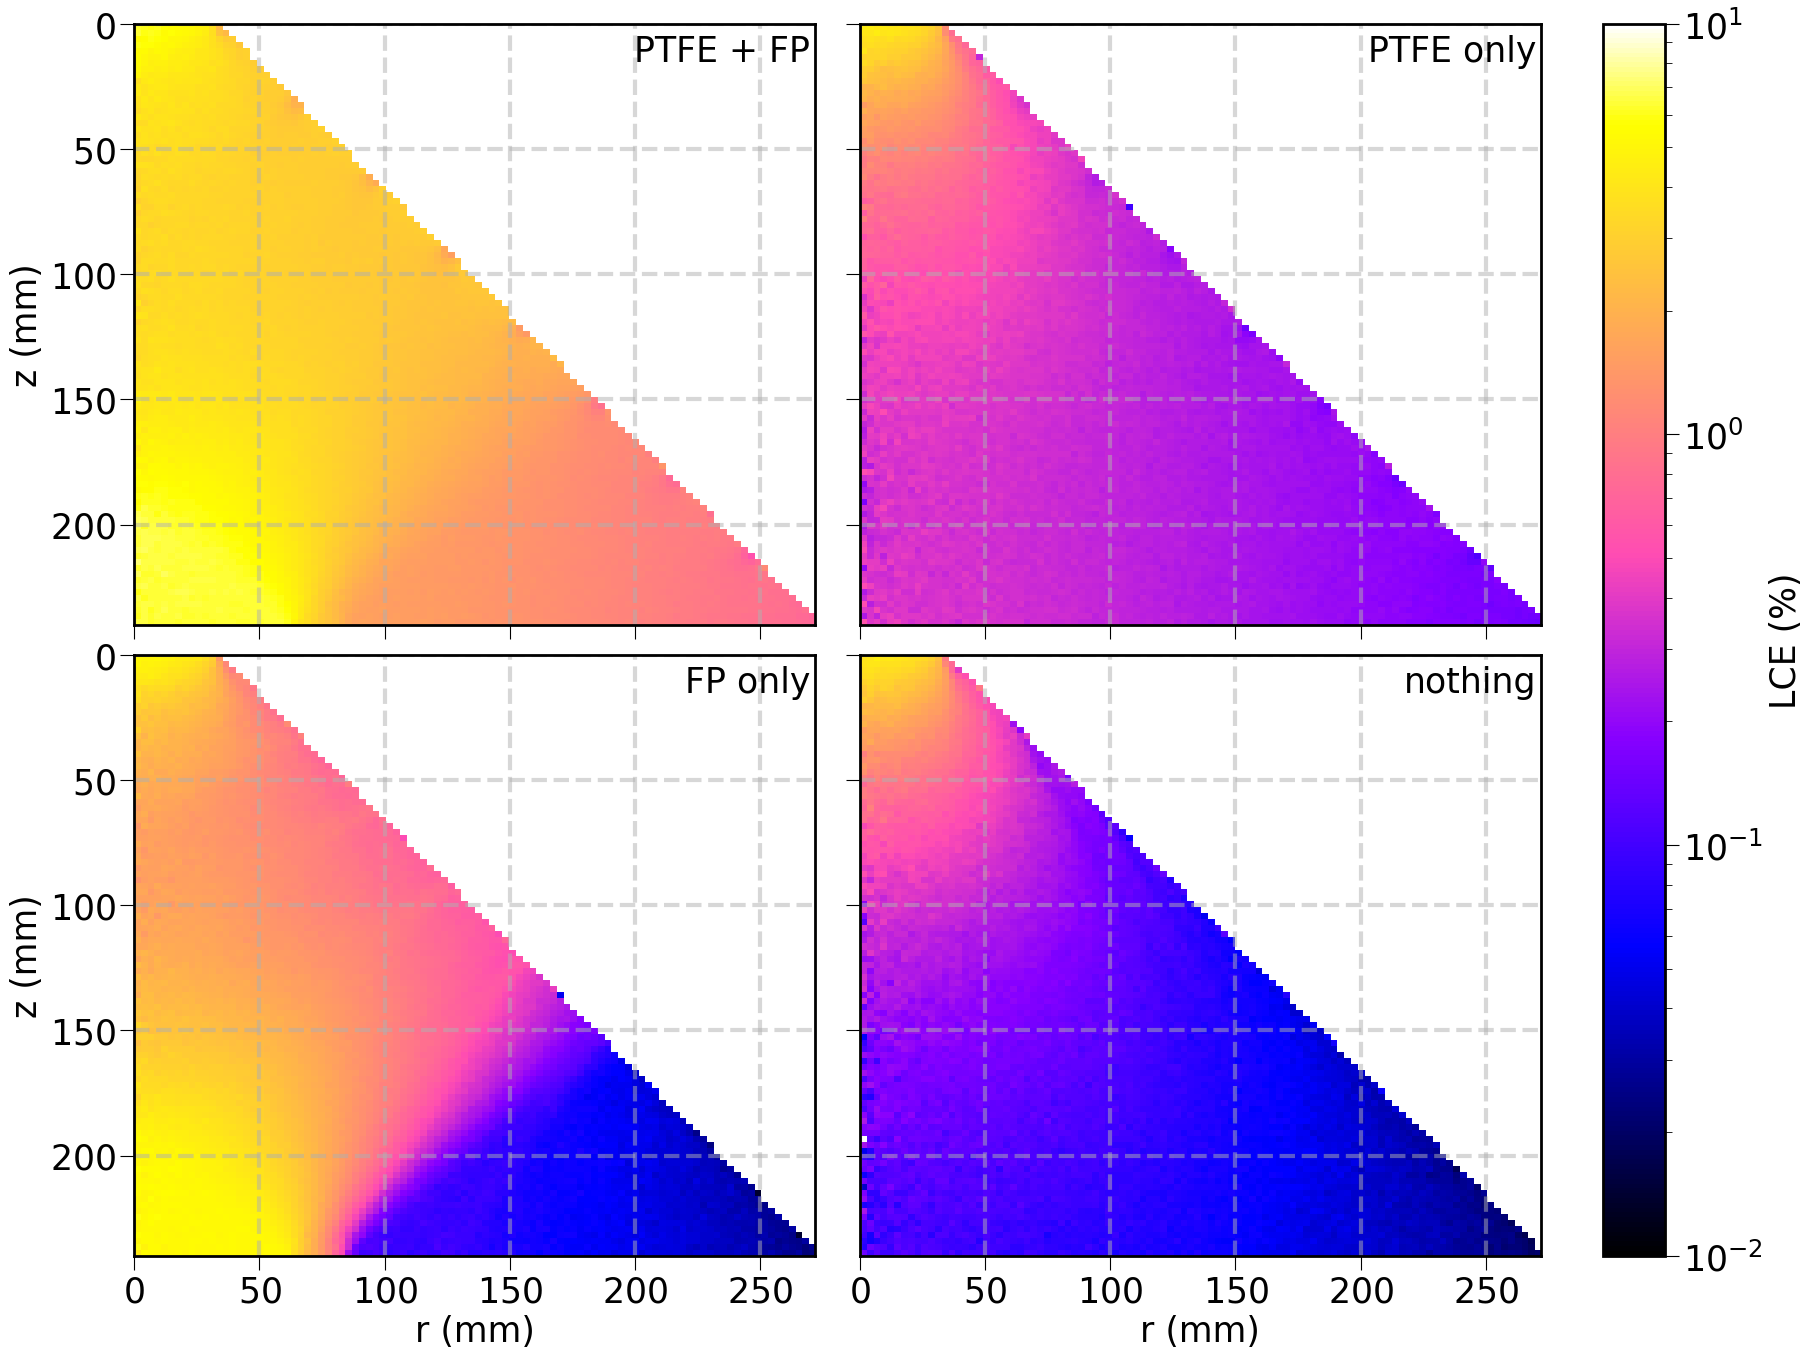

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16), sharex='col', sharey='row', constrained_layout=False)
fig.subplots_adjust(wspace=0.05, hspace=0.05)
axes = axes.ravel().tolist()

norm = LogNorm(vmin=1e-2, vmax=10)
k=0
for title, df in dfs.items():
    ax = axes[k]; k+=1
    
    nevt = np.histogram2d(df.rho, -df.z, 100)[0]
    lce  = np.histogram2d(df.rho, -df.z, 100, weights=df.lce)[0]
    lce  = np.where(nevt, 100*lce/nevt, np.nan)

    im = ax.imshow(lce.T, origin="lower", extent=(0, 32+240, 240, 0), norm=norm)
    
    if k in (3,4): ax.set_xlabel("r (mm)")
    if k in (1,3): ax.set_ylabel("z (mm)")
    ax.text(270, 15, title, fontsize=25, ha="right")
    ax.grid(True)

# Shared colorbar on the right
cbar = fig.colorbar(
    im,
    ax=axes,
    location='right',
    fraction=0.046,
    pad=0.04,
    label="LCE (%)"
)

plt.show()


/tmp/ipykernel_3084750/520352707.py:11: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt, 100*lce/nevt, np.nan)


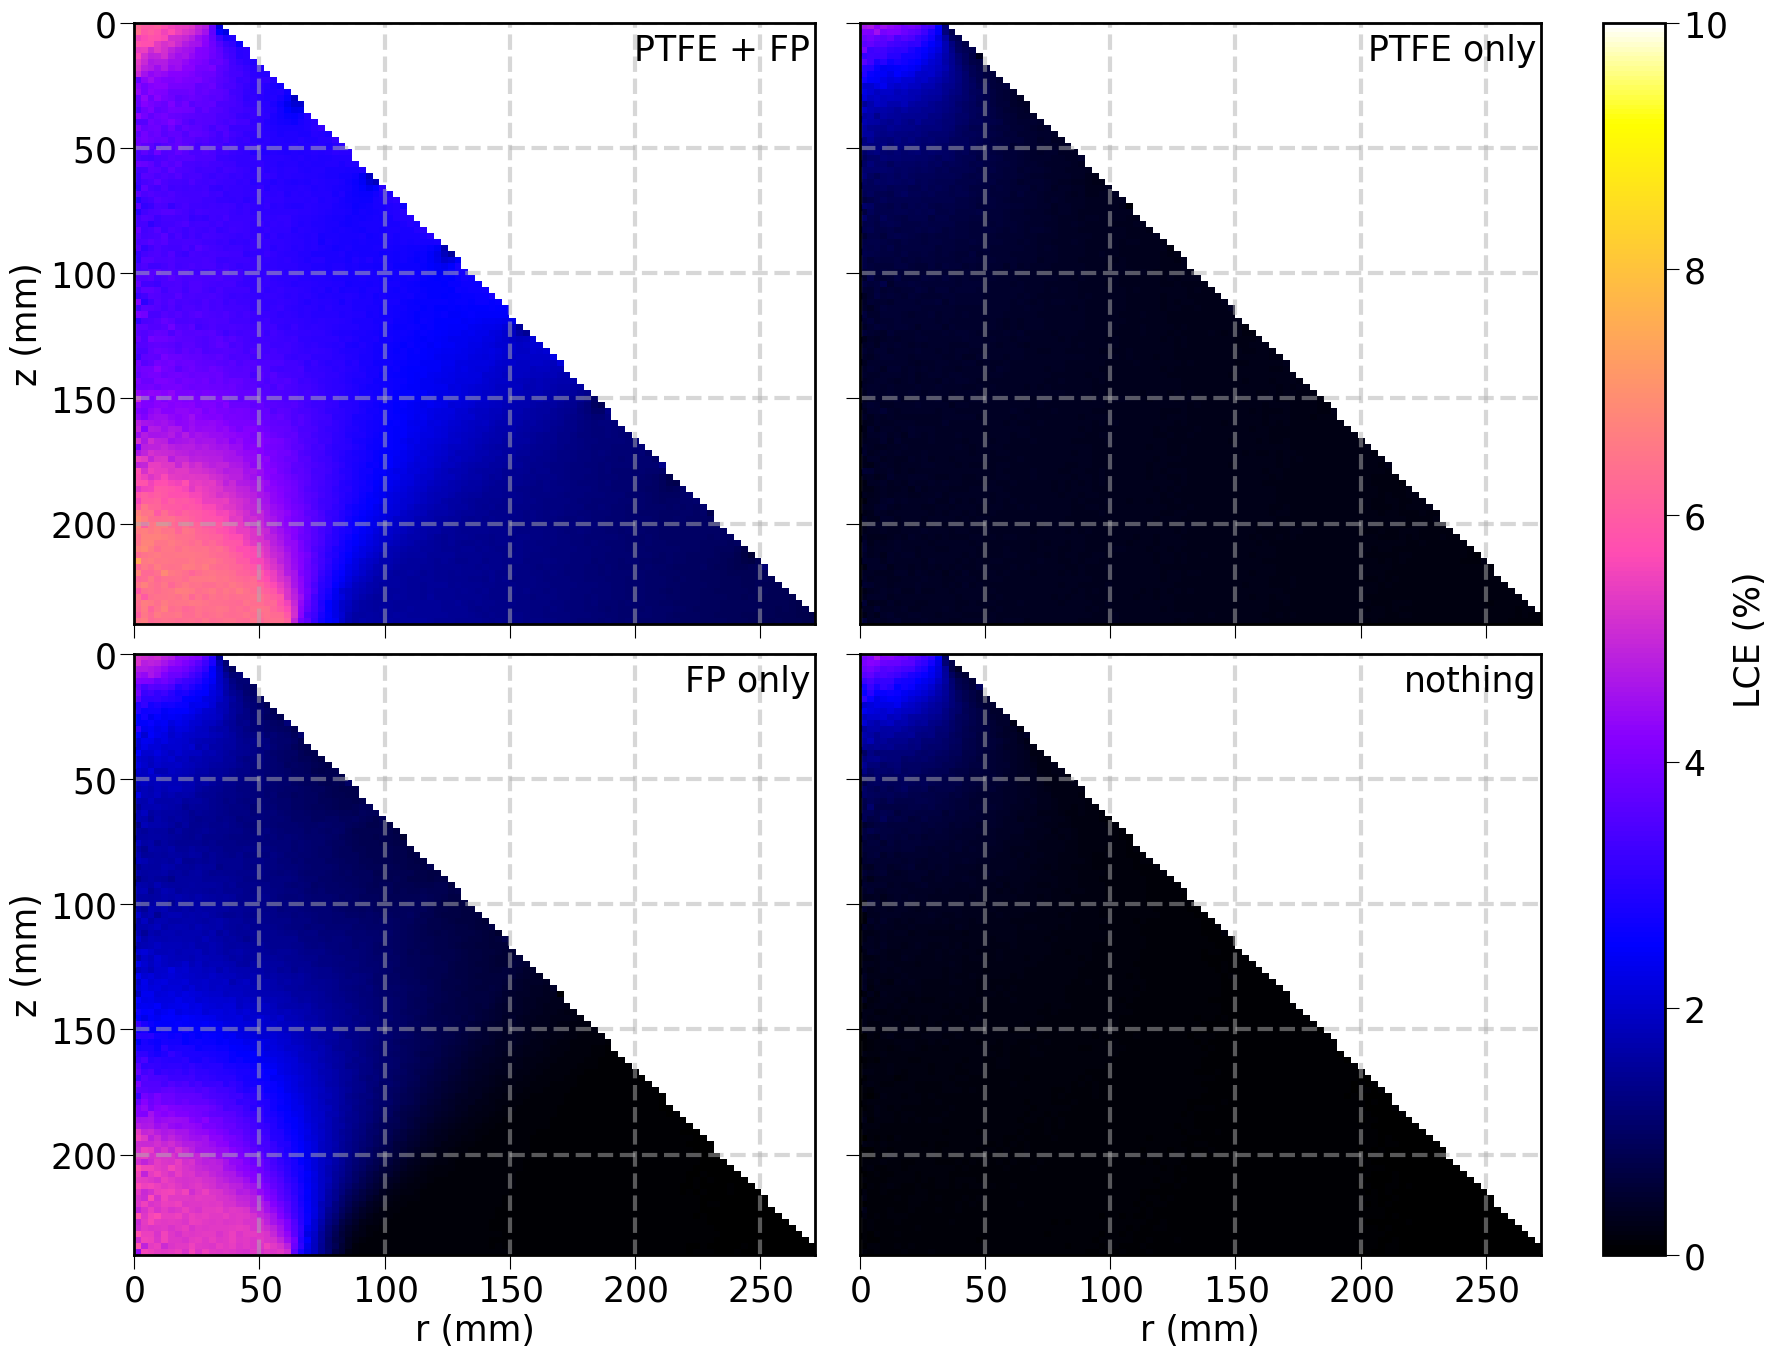

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16), sharex='col', sharey='row', constrained_layout=False)
fig.subplots_adjust(wspace=0.05, hspace=0.05)
axes = axes.ravel().tolist()

k=0
for title, df in dfs.items():
    ax = axes[k]; k+=1
    
    nevt = np.histogram2d(df.rho, -df.z, 100)[0]
    lce  = np.histogram2d(df.rho, -df.z, 100, weights=df.lce)[0]
    lce  = np.where(nevt, 100*lce/nevt, np.nan)

    im = ax.imshow(lce.T, origin="lower", extent=(0, 32+240, 240, 0), vmin=0, vmax=10)
    
    if k in (3,4): ax.set_xlabel("r (mm)")
    if k in (1,3): ax.set_ylabel("z (mm)")
    ax.text(270, 15, title, fontsize=25, ha="right")
    ax.grid(True)

# Shared colorbar on the right
cbar = fig.colorbar(
    im,
    ax=axes,
    location='right',
    fraction=0.046,
    pad=0.04,
    label="LCE (%)"
)

plt.show()


# S2

In [16]:
filename_ptfe_true_fp_true   = path / "s2_ptfe_true_fp_true/merged.h5"
filename_ptfe_true_fp_false  = path / "s2_ptfe_true_fp_false/merged.h5"
filename_ptfe_false_fp_true  = path / "s2_ptfe_false_fp_true/merged.h5"
filename_ptfe_false_fp_false = path / "s2_ptfe_false_fp_false/merged.h5"

In [17]:
c  = np.cos(np.pi/4)
s  = np.sin(np.pi/4)
m  = np.array([[c, -s], [ s, c]])
mi = np.array([[c,  s], [-s, c]])

pitch  =  5.0
z_wire = -5.2
def gate_coords(df):
    x, y = m.dot(df.loc[:, "x y".split()].values.T)
    z    = df.z - z_wire

    x    = ( (np.arctan2(z, x % pitch - 0.5*pitch) - np.pi/2)
           / (np.pi/2)
           * pitch/2
           + (x // pitch) * pitch
           +          0.5 * pitch
           )
    x, y = mi.dot([x, y])

    df.insert(df.shape[1], "x_gate", x)
    df.insert(df.shape[1], "y_gate", y)

In [18]:
s2_interactions = pd.read_hdf(filename_ptfe_true_fp_true, "/MC/interactions")
gate_coords(s2_interactions)

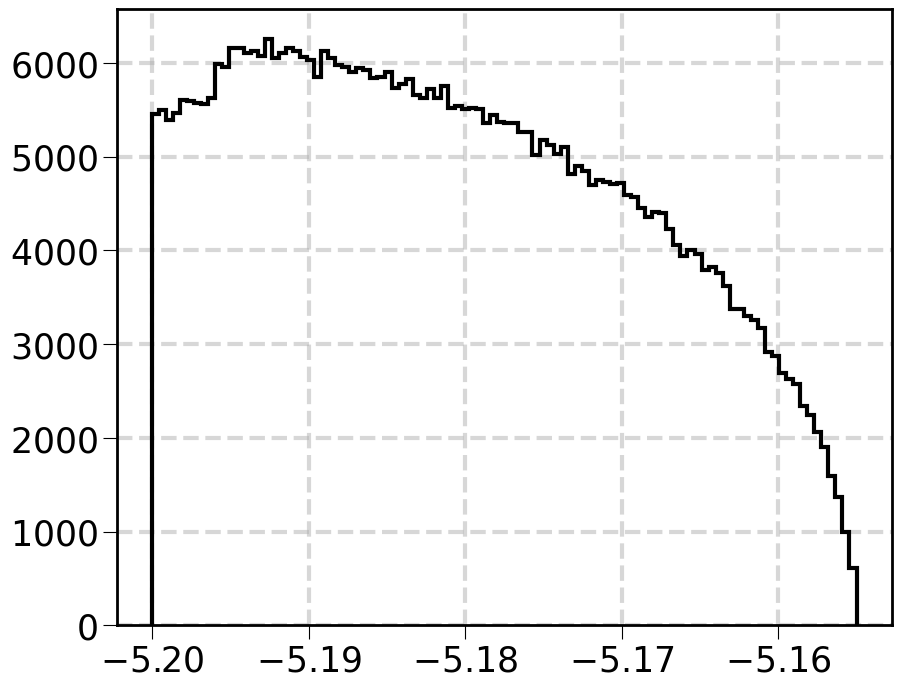

In [19]:
df = s2_interactions

plt.hist(df.z, 100, histtype="step")
plt.grid()

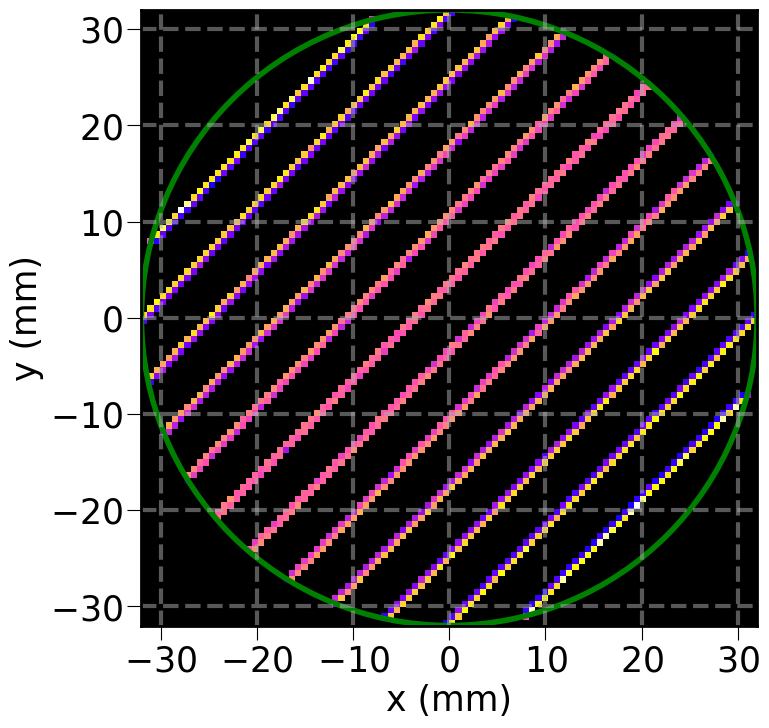

In [20]:
df = s2_interactions

plt.hist2d(df.x, df.y, 100)
c = plt.Circle((0,0), 32, facecolor="None", edgecolor="g", linewidth=4)
plt.gca().add_patch(c)
plt.gca().set_aspect(1)
plt.xticks(plt.yticks()[0][1:-1])
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.grid()

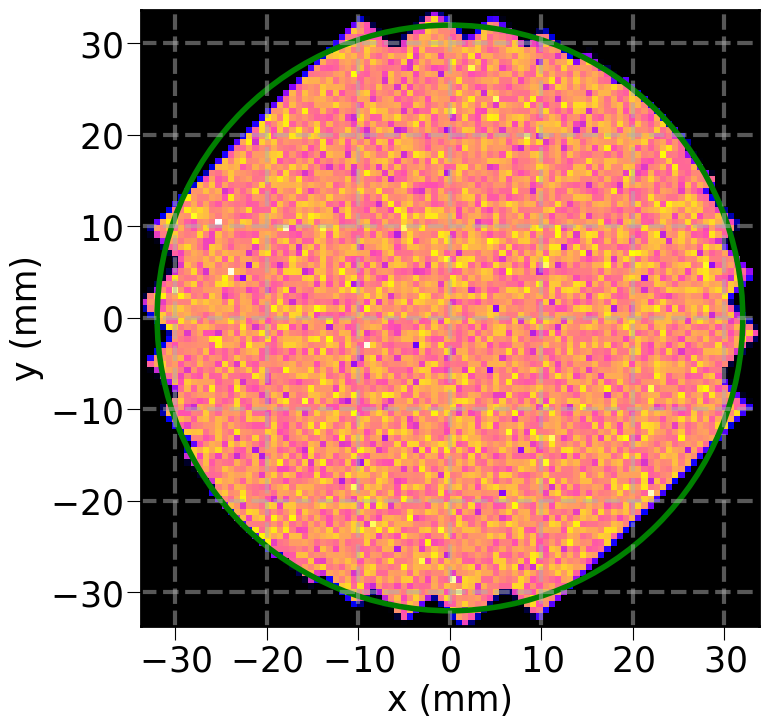

In [21]:
df = s2_interactions

plt.hist2d(df.x_gate, df.y_gate, 100)
c = plt.Circle((0,0), 32, facecolor="None", edgecolor="g", linewidth=4)
plt.gca().add_patch(c)
plt.gca().set_aspect(1)
plt.xticks(plt.yticks()[0][1:-1])
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.grid()

In [22]:
int_true_true   = pd.read_hdf(filename_ptfe_true_fp_true  , "/MC/interactions"); gate_coords(int_true_true  )
int_true_false  = pd.read_hdf(filename_ptfe_true_fp_false , "/MC/interactions"); gate_coords(int_true_false )
int_false_true  = pd.read_hdf(filename_ptfe_false_fp_true , "/MC/interactions"); gate_coords(int_false_true )
int_false_false = pd.read_hdf(filename_ptfe_false_fp_false, "/MC/interactions"); gate_coords(int_false_false)

ss_true_true   = pd.read_hdf(filename_ptfe_true_fp_true  , "/MC/sensor_hits")
ss_true_false  = pd.read_hdf(filename_ptfe_true_fp_false , "/MC/sensor_hits")
ss_false_true  = pd.read_hdf(filename_ptfe_false_fp_true , "/MC/sensor_hits")
ss_false_false = pd.read_hdf(filename_ptfe_false_fp_false, "/MC/sensor_hits")

In [23]:
counts_true_true   = compute_lce(int_true_true  , ss_true_true  )
counts_true_false  = compute_lce(int_true_false , ss_true_false )
counts_false_true  = compute_lce(int_false_true , ss_false_true )
counts_false_false = compute_lce(int_false_false, ss_false_false)

/tmp/ipykernel_3084750/1683575742.py:11: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt>0, 100*lce/nevt, np.nan)


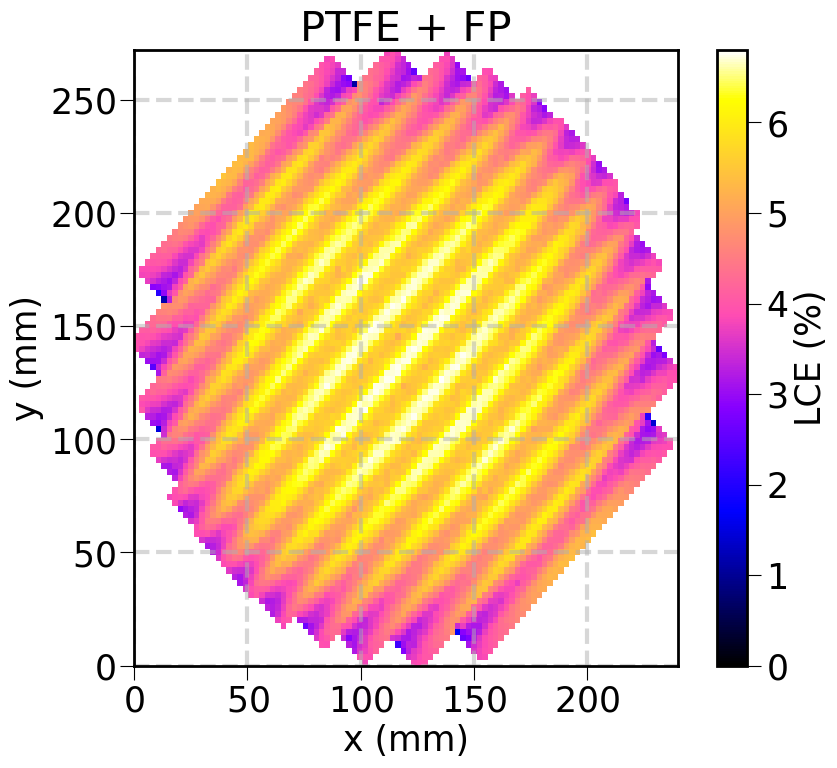

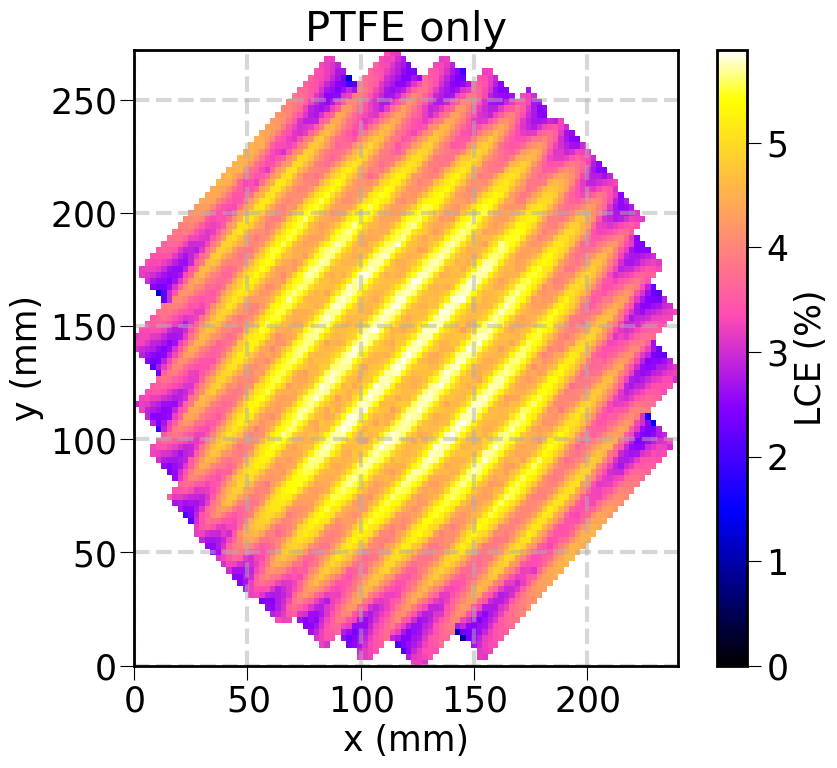

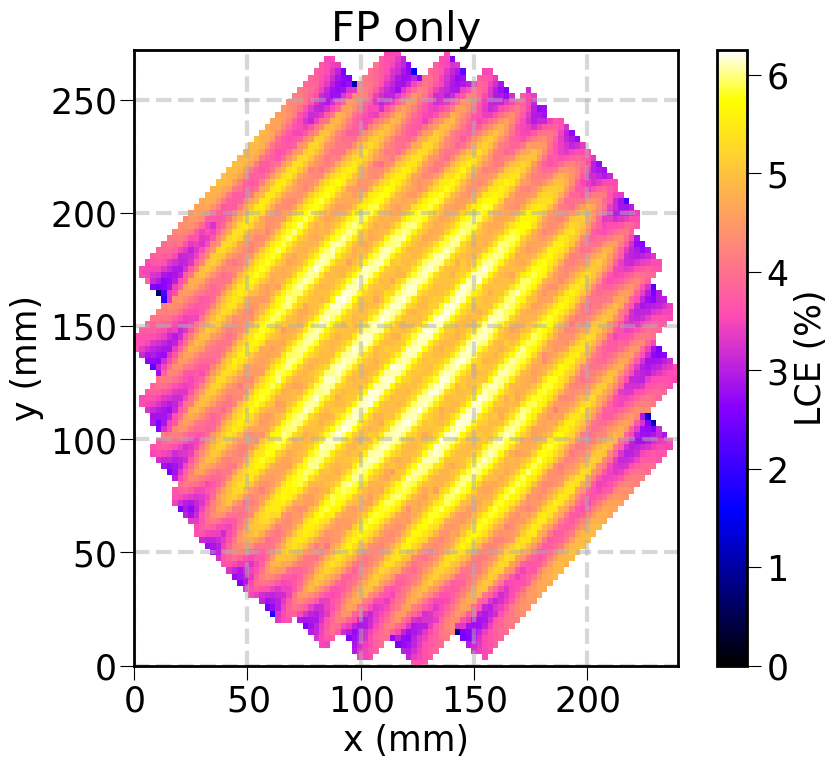

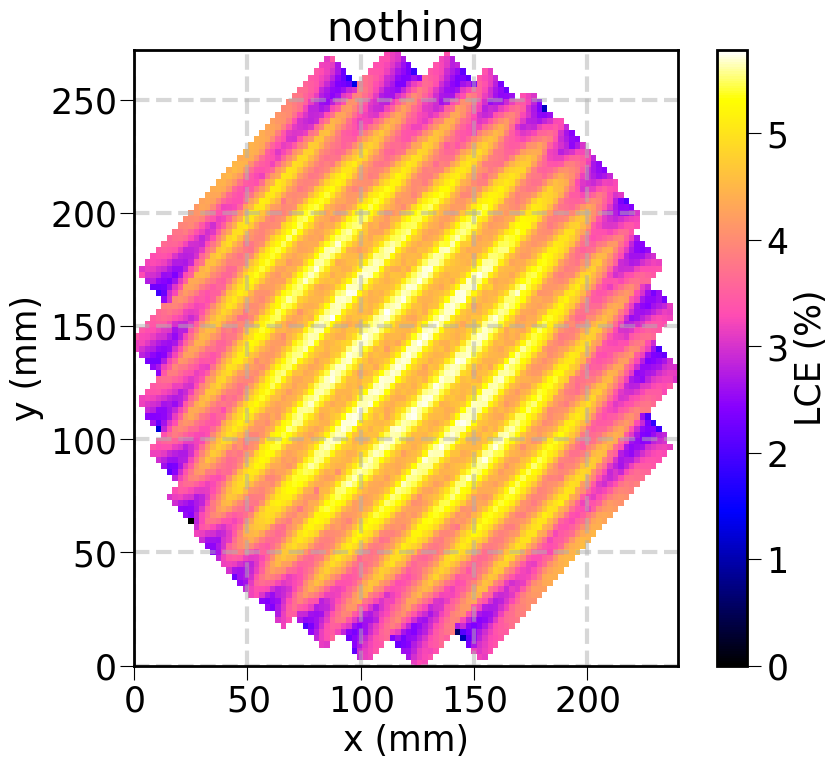

In [24]:
dfs = {
"PTFE + FP" : counts_true_true  ,
"PTFE only" : counts_true_false ,
"FP only"   : counts_false_true ,
"nothing"   : counts_false_false,
}

for title, df in dfs.items():
    nevt = np.histogram2d(df.x_gate, df.y_gate, 100)[0]
    lce  = np.histogram2d(df.x_gate, df.y_gate, 100, weights=df.lce)[0]
    lce  = np.where(nevt>0, 100*lce/nevt, np.nan)

    plt.figure()
    plt.imshow(lce.T, origin="lower", extent=(0, 240, 0, 32+240), vmin=0)

    plt.colorbar().set_label("LCE (%)")
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title(title)
    plt.grid()

/tmp/ipykernel_3084750/1381862603.py:14: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt, 100*lce/nevt, np.nan)


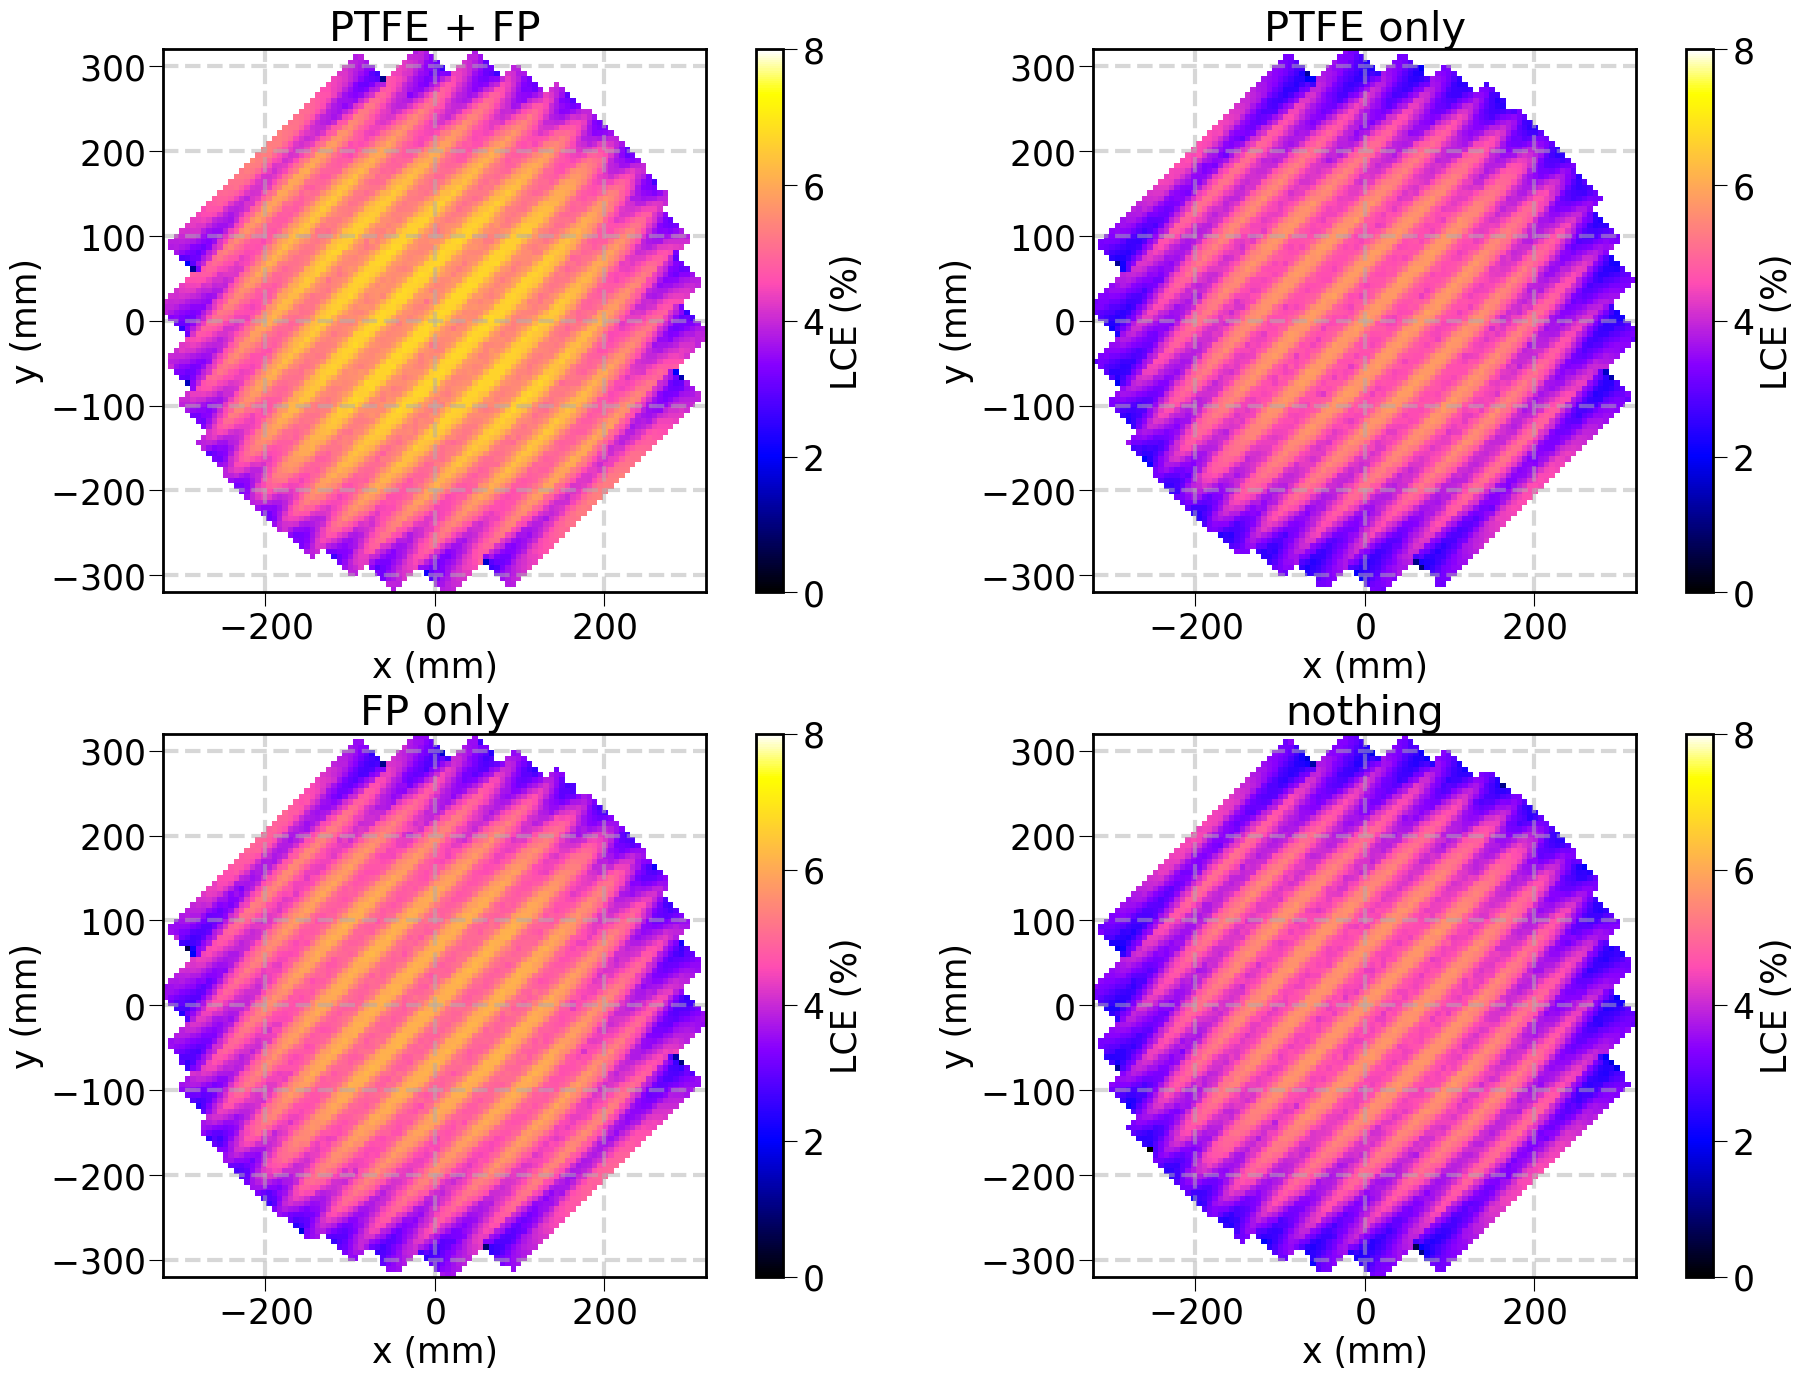

In [25]:
dfs = {
"PTFE + FP" : counts_true_true  ,
"PTFE only" : counts_true_false ,
"FP only"   : counts_false_true ,
"nothing"   : counts_false_false,
}

plt.figure(figsize=(20,20))
k = 0
for title, df in dfs.items():
    k += 1
    nevt = np.histogram2d(df.x_gate, df.y_gate, 100)[0]
    lce  = np.histogram2d(df.x_gate, df.y_gate, 100, weights=df.lce)[0]
    lce  = np.where(nevt, 100*lce/nevt, np.nan)

    plt.subplot(2, 2, k)
    plt.imshow(lce.T, origin="lower", extent=(-320, 320, -320, 320), vmin=0, vmax=8)
    
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title(title)
    plt.grid()

    divider = make_axes_locatable(plt.gca())
    cax = divider.append_axes("right", size="5%", pad=0.5)
    
    cb = plt.colorbar(cax=cax)
    cb.set_label("LCE (%)")
    
plt.subplots_adjust(wspace=.5, hspace=-0.2)

/tmp/ipykernel_3084750/3490472795.py:14: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt, 100*lce/nevt, np.nan)


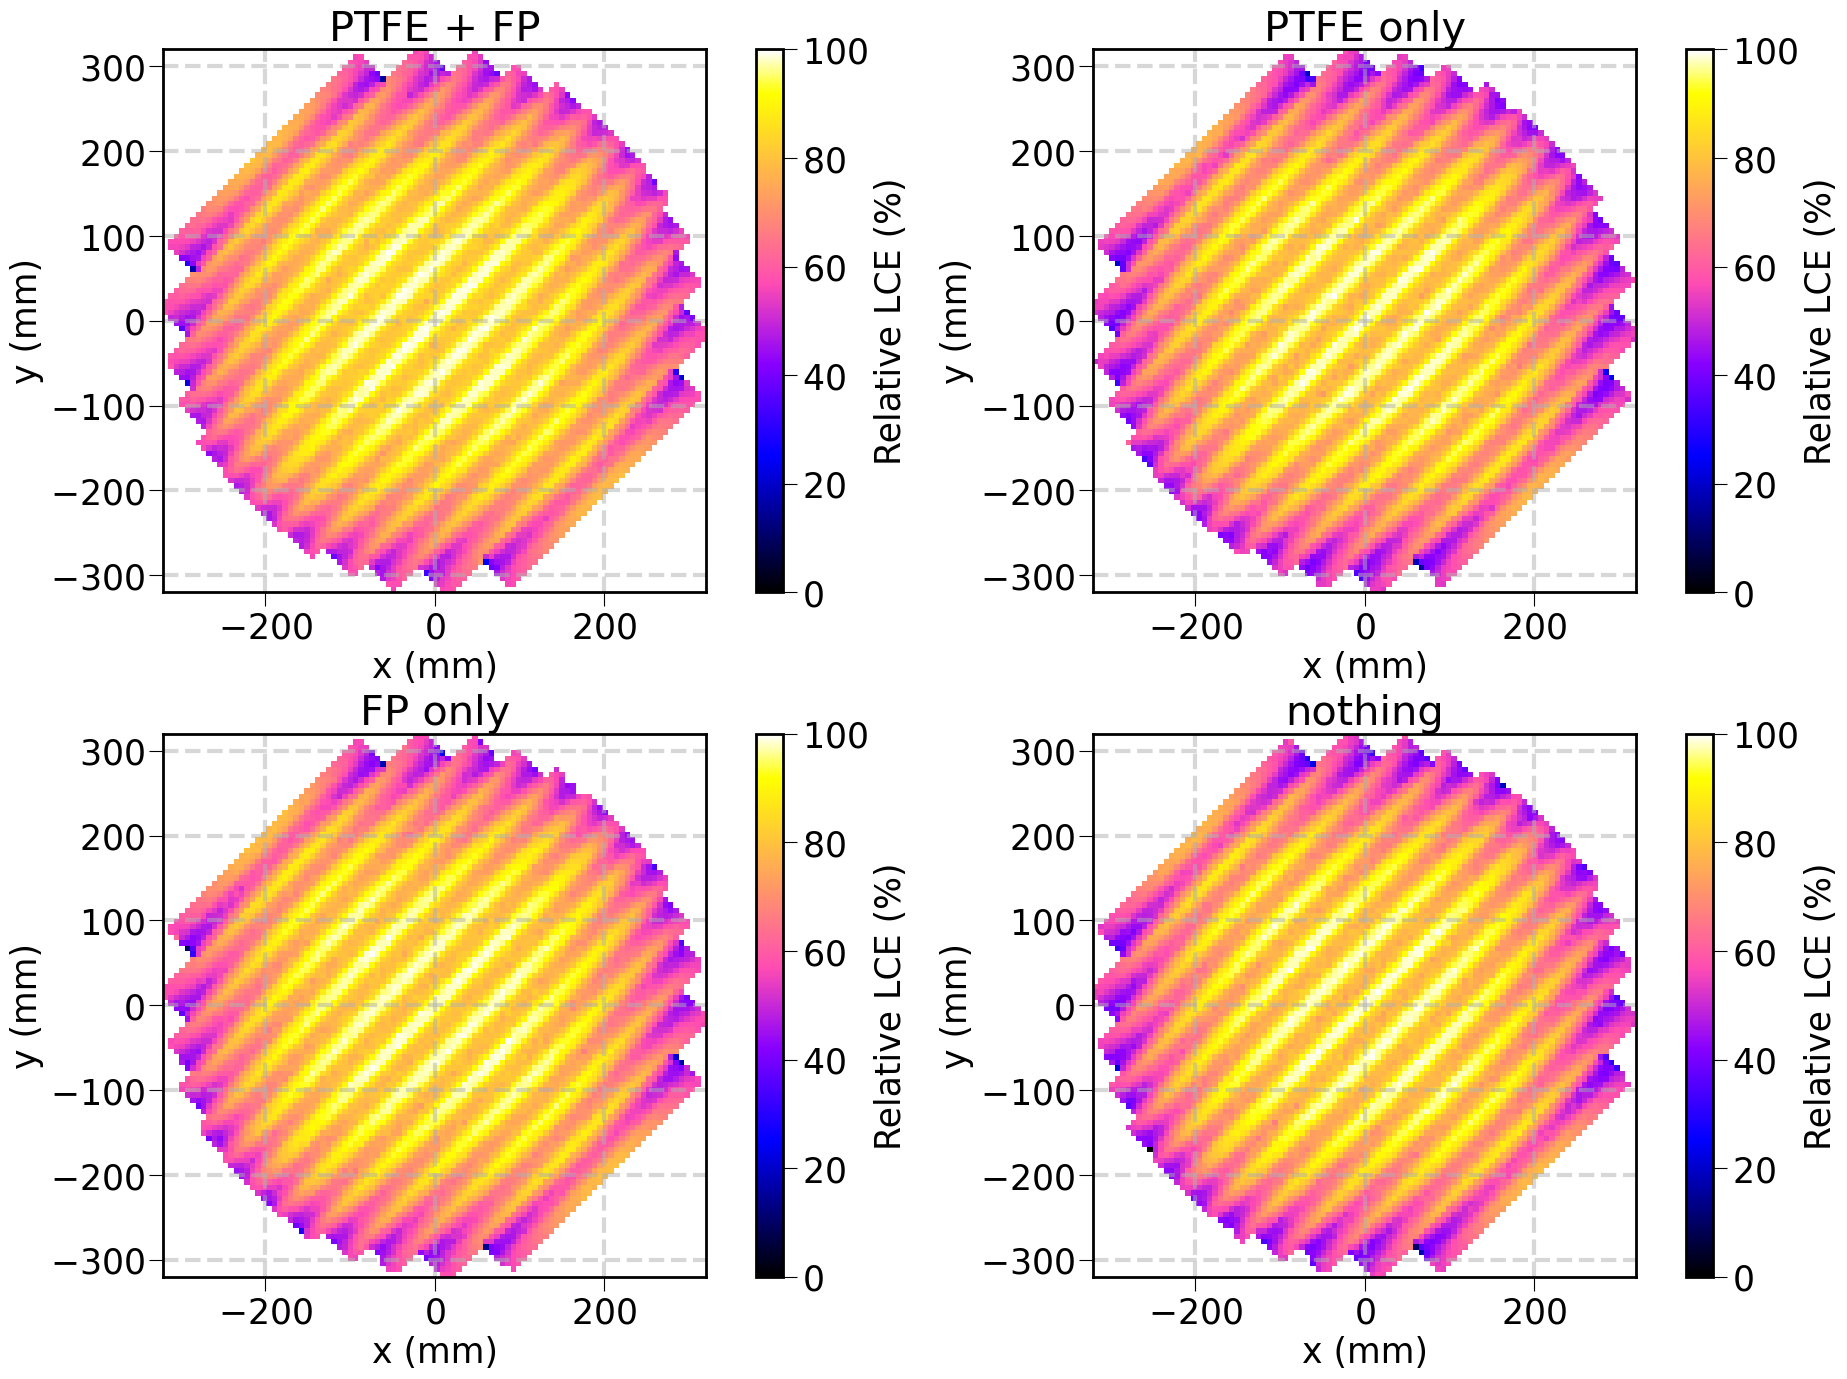

In [26]:
dfs = {
"PTFE + FP" : counts_true_true  ,
"PTFE only" : counts_true_false ,
"FP only"   : counts_false_true ,
"nothing"   : counts_false_false,
}

plt.figure(figsize=(20,20))
k = 0
for title, df in dfs.items():
    k += 1
    nevt = np.histogram2d(df.x_gate, df.y_gate, 100)[0]
    lce  = np.histogram2d(df.x_gate, df.y_gate, 100, weights=df.lce)[0]
    lce  = np.where(nevt, 100*lce/nevt, np.nan)
    lce  = lce / np.nanmax(lce) * 100

    plt.subplot(2, 2, k)
    plt.imshow(lce.T, origin="lower", extent=(-320, 320, -320, 320), vmin=0, vmax=100)
    
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title(title)
    plt.grid()

    divider = make_axes_locatable(plt.gca())
    cax = divider.append_axes("right", size="5%", pad=0.5)
    
    cb = plt.colorbar(cax=cax)
    cb.set_label("Relative LCE (%)")
    
plt.subplots_adjust(wspace=.5, hspace=-0.2)

/tmp/ipykernel_3084750/4162849260.py:11: RuntimeWarning: invalid value encountered in divide
  lce  = np.where(nevt, 100*lce/nevt, np.nan)


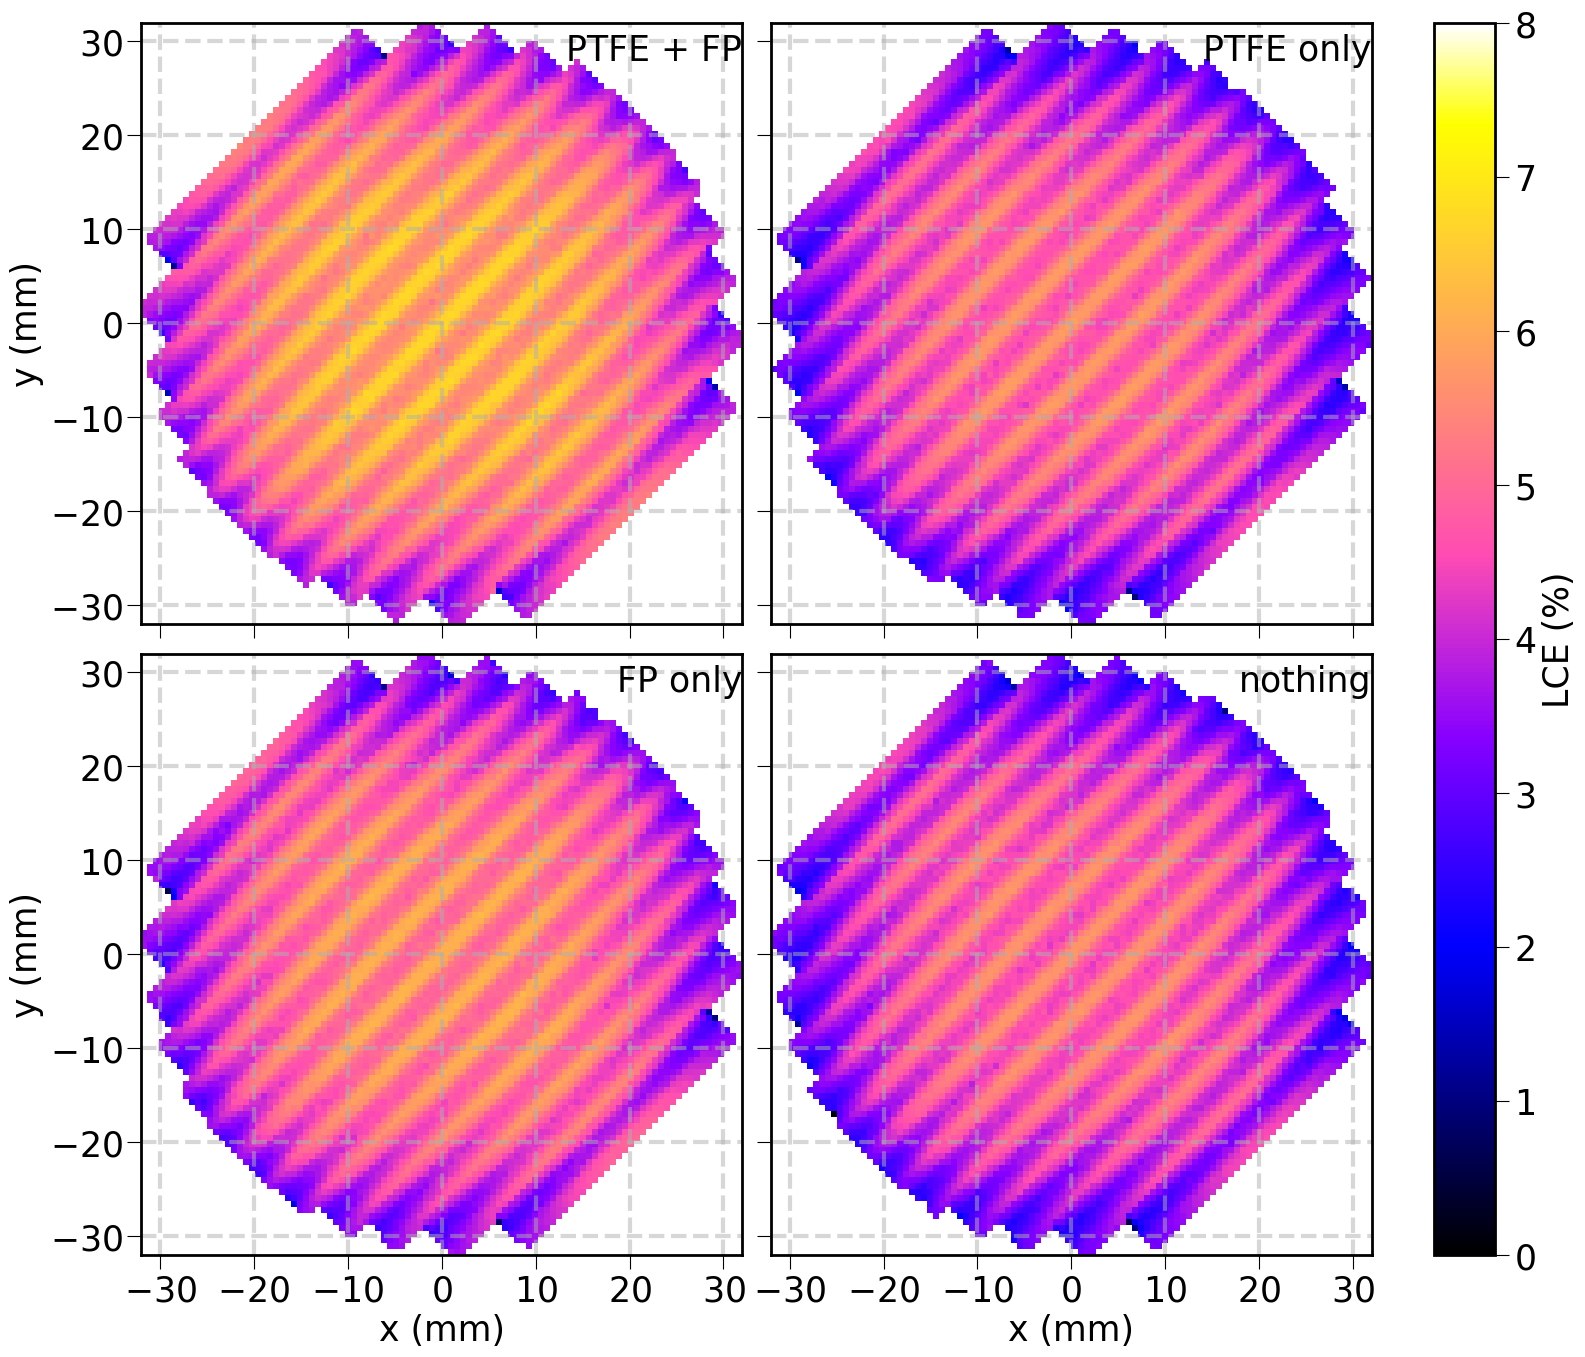

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16), sharex='col', sharey='row', constrained_layout=False)
fig.subplots_adjust(wspace=-0.2, hspace=0.05)
axes = axes.ravel().tolist()

k=0
for title, df in dfs.items():
    ax = axes[k]; k+=1
    
    nevt = np.histogram2d(df.x_gate, df.y_gate, 100)[0]
    lce  = np.histogram2d(df.x_gate, df.y_gate, 100, weights=df.lce)[0]
    lce  = np.where(nevt, 100*lce/nevt, np.nan)

    im = ax.imshow(lce.T, origin="lower", extent=(-32, 32, -32, 32), vmin=0, vmax=8)
    
    if k in (3,4): ax.set_xlabel("x (mm)")
    if k in (1,3): ax.set_ylabel("y (mm)")
    ax.text(32, 28, title, fontsize=25, ha="right")
    ax.set_xticks(ax.get_yticks()[1:-1])
    ax.grid(True)

# Shared colorbar on the right
cbar = fig.colorbar(
    im,
    ax=axes,
    location='right',
    fraction=0.046,
    pad=0.04,
    label="LCE (%)"
)

plt.show()
